# Testing Qiskit Circuit Conversion to DAG

## Install Packages

In [1]:
!pip install qiskit -qqq

print("Packages installed Successfully.")

Packages installed Successfully.


## Import Packages

In [2]:
from qiskit import QuantumCircuit

## Simple Quantum Program

In [3]:
num_rows = 3
qc_entangled = QuantumCircuit(2 * num_rows, 2 * num_rows)
for i in range(num_rows):
    qc_entangled.h(i)
    qc_entangled.cx(i, i + num_rows)
    qc_entangled.measure(i, i)
    qc_entangled.measure(i + num_rows, i + num_rows)

qc_entangled.draw(fold=-1)

┌───┐               ┌─┐               
q_0: ┤ H ├──■────────────┤M├───────────────
     ├───┤  │            └╥┘   ┌─┐         
q_1: ┤ H ├──┼────■────────╫────┤M├─────────
     ├───┤  │    │        ║    └╥┘   ┌─┐   
q_2: ┤ H ├──┼────┼────■───╫─────╫────┤M├───
     └───┘┌─┴─┐  │    │   ║ ┌─┐ ║    └╥┘   
q_3: ─────┤ X ├──┼────┼───╫─┤M├─╫─────╫────
          └───┘┌─┴─┐  │   ║ └╥┘ ║ ┌─┐ ║    
q_4: ──────────┤ X ├──┼───╫──╫──╫─┤M├─╫────
               └───┘┌─┴─┐ ║  ║  ║ └╥┘ ║ ┌─┐
q_5: ───────────────┤ X ├─╫──╫──╫──╫──╫─┤M├
                    └───┘ ║  ║  ║  ║  ║ └╥┘
c: 6/═════════════════════╩══╩══╩══╩══╩══╩═
                          0  3  1  4  2  5

## Decompose Qiskit Circuit

In [4]:
qc_dec = qc_entangled.decompose()
qc_dec.draw(fold=-1)

┌────────────┐               ┌─┐               
q_0: ┤ U(π/2,0,π) ├──■────────────┤M├───────────────
     ├────────────┤  │            └╥┘┌─┐            
q_1: ┤ U(π/2,0,π) ├──┼────■────────╫─┤M├────────────
     ├────────────┤  │    │        ║ └╥┘┌─┐         
q_2: ┤ U(π/2,0,π) ├──┼────┼────■───╫──╫─┤M├─────────
     └────────────┘┌─┴─┐  │    │   ║  ║ └╥┘┌─┐      
q_3: ──────────────┤ X ├──┼────┼───╫──╫──╫─┤M├──────
                   └───┘┌─┴─┐  │   ║  ║  ║ └╥┘┌─┐   
q_4: ───────────────────┤ X ├──┼───╫──╫──╫──╫─┤M├───
                        └───┘┌─┴─┐ ║  ║  ║  ║ └╥┘┌─┐
q_5: ────────────────────────┤ X ├─╫──╫──╫──╫──╫─┤M├
                             └───┘ ║  ║  ║  ║  ║ └╥┘
c: 6/══════════════════════════════╩══╩══╩══╩══╩══╩═
                                   0  1  2  3  4  5

## Import More Packages

In [5]:
%pip install networkx -qqq
%pip install graphviz -qqq

print("Packages installed Successfully.")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Packages installed Successfully.


In [6]:
%cd ..

# from src.dag import QuantumDAG
from src.convert import from_qiskit, from_qasm_file

/workspaces/sqa26pro16


## Converting Decomposed Qiskit Circuit to DAG

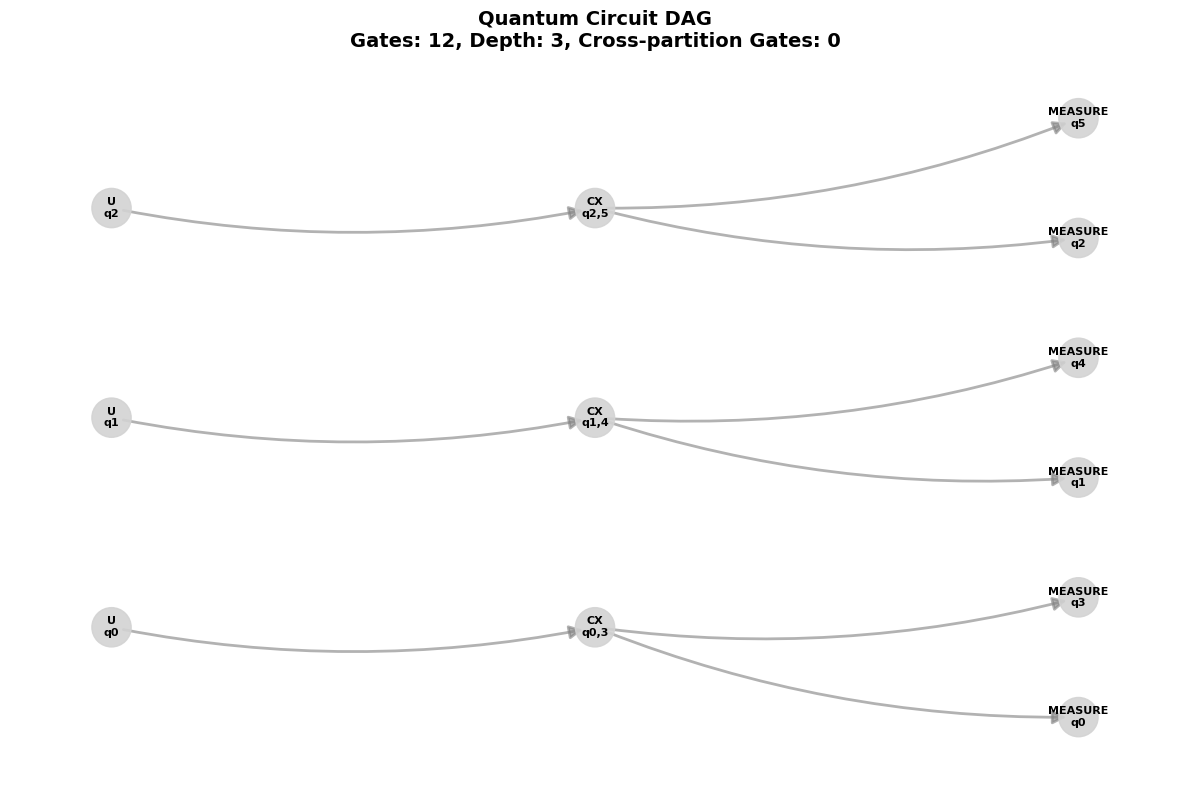

In [7]:
dag = from_qiskit(qc_dec)
dag.draw()

## Verifying Against Qiskit Converter

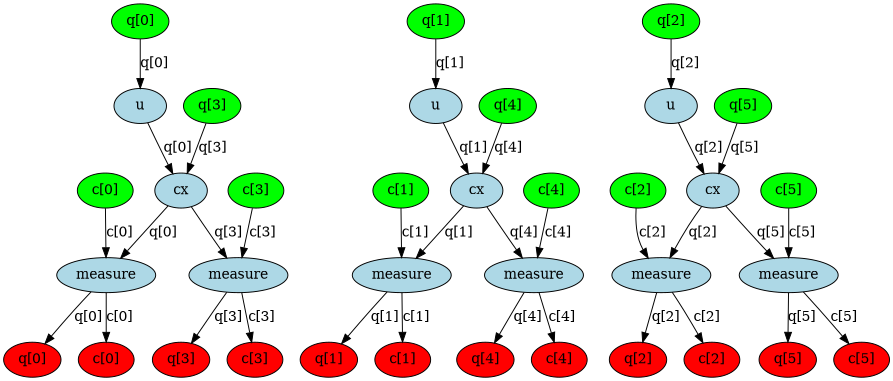

In [8]:
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer

qiskit_dag = circuit_to_dag(qc_dec)

dag_drawer(qiskit_dag)